# Stock Movement Predictor — AAPL Next-Day Direction Classifier

**Project idea #3 from the board.** Predict whether AAPL closes up or down the next trading day, using engineered features (lagged returns, moving averages, volatility) and a classifier — evaluated rigorously against real baselines, not just reported in isolation.

**Set your expectations correctly before reading further:** predicting stock direction is one of the hardest problems in applied ML. Markets are close to efficient — if a pattern this simple reliably predicted direction, it would already be arbitraged away. A 'credible' result here looks like **52-56% accuracy**, not 90%. This notebook is honest about that the whole way through — the value is in the rigor (proper time-based validation, real baselines, walk-forward testing), not in an inflated headline number.

## 1. Setup & Data

Real daily AAPL data (1980-2024, 11,084 trading days), sourced from a public GitHub mirror of Yahoo Finance data — Yahoo Finance's own API is blocked in this sandboxed environment, so a static historical dataset was used instead of live `yfinance` calls.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')
df = pd.read_csv('data/aapl_1980_2024.csv')
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values('Date').reset_index(drop=True)
print('Shape:', df.shape)
df.head()

Shape: (11084, 6)


,Date,Open,High,Low,Close,Volume
0,1980-12-12 05:00:00+00:00,0.098834,0.099264,0.098834,0.098834,469033600
1,1980-12-15 05:00:00+00:00,0.094108,0.094108,0.093678,0.093678,175884800
2,1980-12-16 05:00:00+00:00,0.087232,0.087232,0.086802,0.086802,105728000
3,1980-12-17 05:00:00+00:00,0.088951,0.089381,0.088951,0.088951,86441600
4,1980-12-18 05:00:00+00:00,0.091530,0.091959,0.091530,0.091530,73449600


## 2. Restricting to a Modern, Relevant Period

AAPL in 1981 (a struggling early PC company) behaves nothing like AAPL today. We restrict to **2005 onward** — post-iPod, a more stable modern trading regime relevant to what we'd want a model to generalize to.

In [2]:
modern = df[df['Date'] >= '2005-01-01'].copy().reset_index(drop=True)
print('Modern period shape:', modern.shape)
print('Date range:', modern['Date'].min(), 'to', modern['Date'].max())

Modern period shape: (5012, 6)
Date range: 2005-01-03 05:00:00+00:00 to 2024-11-29 05:00:00+00:00


## 3. Visualize the Price History

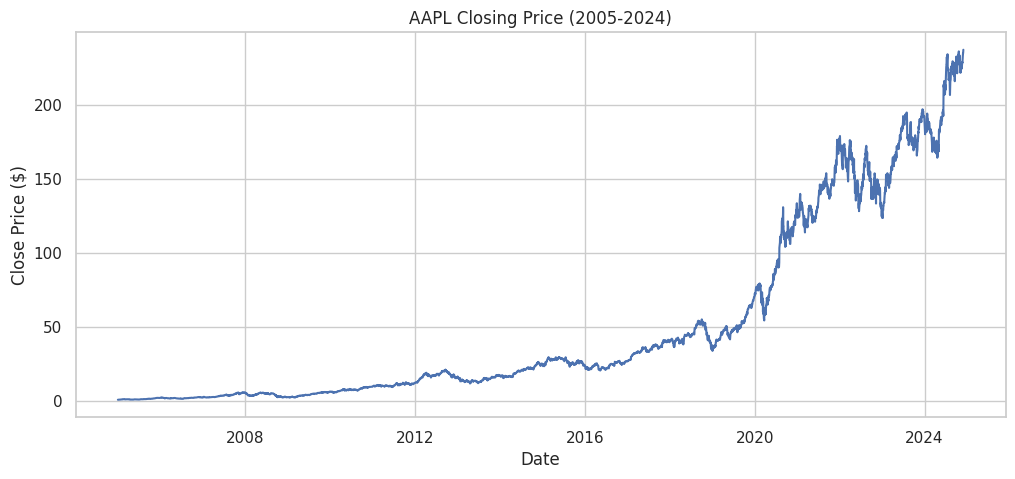

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(modern['Date'], modern['Close'])
plt.title('AAPL Closing Price (2005-2024)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.show()

## 4. Feature Engineering — Lagged Returns

In [4]:
modern['return_1d'] = modern['Close'].pct_change(1)
modern['return_2d'] = modern['Close'].pct_change(2)
modern['return_5d'] = modern['Close'].pct_change(5)
modern['return_10d'] = modern['Close'].pct_change(10)
modern[['Date', 'Close', 'return_1d', 'return_5d', 'return_10d']].tail(10)

,Date,Close,return_1d,return_5d,return_10d
5002,2024-11-15 05:00:00+00:00,225.000000,-0.014109,-0.008636,0.010486
5003,2024-11-18 05:00:00+00:00,228.020004,0.013422,0.016902,0.028201
5004,2024-11-19 05:00:00+00:00,228.279999,0.001140,0.018062,0.022740
5005,2024-11-20 05:00:00+00:00,229.000000,0.003154,0.017235,0.029328
5006,2024-11-21 05:00:00+00:00,228.520004,-0.002096,0.001315,0.005677
5007,2024-11-22 05:00:00+00:00,229.869995,0.005908,0.021644,0.012822
5008,2024-11-25 05:00:00+00:00,232.869995,0.013051,0.021270,0.038532
5009,2024-11-26 05:00:00+00:00,235.059998,0.009404,0.029700,0.048299
5010,2024-11-27 05:00:00+00:00,234.929993,-0.000553,0.025895,0.043577
5011,2024-11-29 05:00:00+00:00,237.330002,0.010216,0.038552,0.039918


## 5. Feature Engineering — Moving Averages

In [5]:
modern['sma_5'] = modern['Close'].rolling(5).mean()
modern['sma_20'] = modern['Close'].rolling(20).mean()
modern['sma_50'] = modern['Close'].rolling(50).mean()

# Price relative to its moving averages — a common technical signal
modern['price_to_sma20'] = modern['Close'] / modern['sma_20'] - 1
modern['sma5_to_sma20'] = modern['sma_5'] / modern['sma_20'] - 1
modern[['Date', 'Close', 'sma_5', 'sma_20', 'price_to_sma20']].tail(5)

,Date,Close,sma_5,sma_20,price_to_sma20
5007,2024-11-22 05:00:00+00:00,229.869995,228.738000,226.842811,0.013345
5008,2024-11-25 05:00:00+00:00,232.869995,229.707999,226.829136,0.026632
5009,2024-11-26 05:00:00+00:00,235.059998,231.063998,226.911476,0.035911
5010,2024-11-27 05:00:00+00:00,234.929993,232.249997,227.165620,0.034179
5011,2024-11-29 05:00:00+00:00,237.330002,234.011996,227.749033,0.042068


## 6. Feature Engineering — Volatility

In [6]:
modern['volatility_5d'] = modern['return_1d'].rolling(5).std()
modern['volatility_20d'] = modern['return_1d'].rolling(20).std()
modern[['Date', 'return_1d', 'volatility_5d', 'volatility_20d']].tail(5)

,Date,return_1d,volatility_5d,volatility_20d
5007,2024-11-22 05:00:00+00:00,0.005908,0.005874,0.010570
5008,2024-11-25 05:00:00+00:00,0.013051,0.005730,0.010810
5009,2024-11-26 05:00:00+00:00,0.009404,0.005807,0.011012
5010,2024-11-27 05:00:00+00:00,-0.000553,0.006445,0.010382
5011,2024-11-29 05:00:00+00:00,0.010216,0.005224,0.009501


## 7. Feature Engineering — RSI (Relative Strength Index)

A classic momentum indicator: measures whether a stock is overbought or oversold based on recent gains vs losses.

In [7]:
def compute_rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

modern['rsi_14'] = compute_rsi(modern['Close'])
modern[['Date', 'Close', 'rsi_14']].tail(5)

,Date,Close,rsi_14
5007,2024-11-22 05:00:00+00:00,229.869995,67.646248
5008,2024-11-25 05:00:00+00:00,232.869995,69.706403
5009,2024-11-26 05:00:00+00:00,235.059998,74.215664
5010,2024-11-27 05:00:00+00:00,234.929993,68.024337
5011,2024-11-29 05:00:00+00:00,237.330002,72.073193


## 8. Feature Engineering — Volume Signals

In [8]:
modern['volume_change'] = modern['Volume'].pct_change(1)
modern['volume_sma_20'] = modern['Volume'].rolling(20).mean()
modern['volume_relative'] = modern['Volume'] / modern['volume_sma_20']
modern[['Date', 'Volume', 'volume_relative']].tail(5)

,Date,Volume,volume_relative
5007,2024-11-22 05:00:00+00:00,38168300,0.870958
5008,2024-11-25 05:00:00+00:00,90152800,1.937660
5009,2024-11-26 05:00:00+00:00,45986200,0.977284
5010,2024-11-27 05:00:00+00:00,33498400,0.722315
5011,2024-11-29 05:00:00+00:00,28481400,0.638854


## 9. Defining the Target — Next-Day Direction

**Critical detail: we predict TOMORROW's direction using only TODAY's (and earlier) data.** Getting this shift wrong is the #1 way stock prediction projects silently cheat by leaking the future into the features.

In [9]:
modern['next_day_return'] = modern['Close'].shift(-1) / modern['Close'] - 1
modern['target'] = (modern['next_day_return'] > 0).astype(int)

print('Class balance:')
print(modern['target'].value_counts(normalize=True).round(4))

Class balance:
target
1    0.5303
0    0.4697
Name: proportion, dtype: float64


## 10. Final Feature Set & Cleanup

In [10]:
feature_cols = [
    'return_1d', 'return_2d', 'return_5d', 'return_10d',
    'price_to_sma20', 'sma5_to_sma20',
    'volatility_5d', 'volatility_20d',
    'rsi_14', 'volume_relative'
]

model_data = modern.dropna(subset=feature_cols + ['target']).copy()
print('Rows after dropping NaN (rolling windows need warm-up):', model_data.shape)
model_data[feature_cols].describe()

Rows after dropping NaN (rolling windows need warm-up): (4992, 23)


,return_1d,return_2d,return_5d,return_10d,price_to_sma20,sma5_to_sma20,volatility_5d,volatility_20d,rsi_14,volume_relative
count,4992.000000,4992.000000,4992.000000,4992.000000,4992.000000,4992.000000,4992.000000,4992.000000,4992.000000,4992.000000
mean,0.001272,0.002540,0.006352,0.012771,0.010823,0.008341,0.017142,0.018346,55.967087,1.002497
std,0.020237,0.028266,0.044086,0.062645,0.049386,0.038607,0.011028,0.008647,17.796078,0.378538
min,-0.179195,-0.202153,-0.243060,-0.327370,-0.285448,-0.220522,0.000755,0.004558,3.180174,0.235588
25%,-0.008320,-0.011949,-0.018874,-0.024313,-0.018017,-0.014515,0.009777,0.012740,43.003467,0.764763
50%,0.001067,0.002697,0.007426,0.014083,0.013902,0.011013,0.014339,0.016331,56.353695,0.915591
75%,0.011721,0.017836,0.031686,0.052611,0.042370,0.033801,0.021691,0.021704,69.298861,1.142827
max,0.139050,0.242506,0.198342,0.297690,0.174347,0.136201,0.107310,0.074093,97.487648,5.245378


## 11. Time-Based Train/Test Split — Never Shuffle Time Series Data

Shuffling would let the model 'see the future' during training via nearby dates. We split strictly by time: train on the past, test on data the model has genuinely never seen chronologically.

In [11]:
split_idx = int(len(model_data) * 0.8)
train = model_data.iloc[:split_idx]
test = model_data.iloc[split_idx:]

print('Train:', train['Date'].min().date(), 'to', train['Date'].max().date(), f'({len(train)} days)')
print('Test :', test['Date'].min().date(), 'to', test['Date'].max().date(), f'({len(test)} days)')

X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']

Train: 2005-02-01 to 2020-12-09 (3993 days)
Test : 2020-12-10 to 2024-11-29 (999 days)


## 12. Baseline 1 — Naive 'Always Predict Up'

Since stocks trend upward over long periods, always guessing 'up' is a surprisingly strong baseline that any real model must beat.

In [12]:
naive_up_preds = np.ones(len(y_test))
naive_up_acc = accuracy_score(y_test, naive_up_preds)
print(f'Naive "always up" baseline accuracy: {naive_up_acc:.4f}')

Naive "always up" baseline accuracy: 0.5255


## 13. Baseline 2 — Persistence (Predict Same Direction as Yesterday)

In [13]:
persistence_preds = (test['return_1d'] > 0).astype(int)
persistence_acc = accuracy_score(y_test, persistence_preds)
print(f'Persistence baseline accuracy: {persistence_acc:.4f}')

Persistence baseline accuracy: 0.5045


## 14. Scaling Features

In [14]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 15. Model 1 — Logistic Regression

In [15]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)
logreg_preds = logreg.predict(X_test_s)
logreg_acc = accuracy_score(y_test, logreg_preds)
print(f'Logistic Regression accuracy: {logreg_acc:.4f}')

Logistic Regression accuracy: 0.5195


## 16. Model 2 — Random Forest

In [16]:
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f'Random Forest accuracy: {rf_acc:.4f}')

Random Forest accuracy: 0.5195


## 17. Model 3 — Gradient Boosting

In [17]:
gb = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_preds)
print(f'Gradient Boosting accuracy: {gb_acc:.4f}')

Gradient Boosting accuracy: 0.5015


## 18. The Real Comparison — Models vs Baselines

This is the table that actually matters. A model only 'works' if it beats both baselines, not just achieves a headline accuracy number in isolation.

              Approach  Accuracy
0    Naive (always up)  0.525526
2  Logistic Regression  0.519520
3        Random Forest  0.519520
1          Persistence  0.504505
4    Gradient Boosting  0.501502


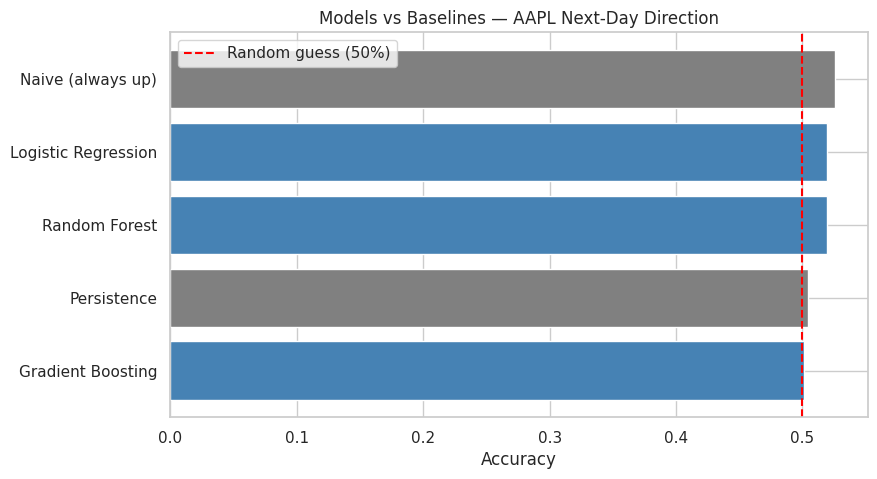

In [18]:
comparison = pd.DataFrame({
    'Approach': ['Naive (always up)', 'Persistence', 'Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [naive_up_acc, persistence_acc, logreg_acc, rf_acc, gb_acc]
}).sort_values('Accuracy', ascending=False)
print(comparison)

plt.figure(figsize=(9, 5))
colors = ['gray' if 'Naive' in a or 'Persistence' in a else 'steelblue' for a in comparison['Approach']]
plt.barh(comparison['Approach'], comparison['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Models vs Baselines — AAPL Next-Day Direction')
plt.axvline(0.5, color='red', linestyle='--', label='Random guess (50%)')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

## 19. Precision/Recall — Does the Model Actually Help on 'Up' Days?

In [19]:
print(classification_report(y_test, gb_preds, target_names=['Down', 'Up']))

              precision    recall  f1-score   support

        Down       0.45      0.21      0.29       474
          Up       0.52      0.76      0.62       525

    accuracy                           0.50       999
   macro avg       0.48      0.49      0.45       999
weighted avg       0.48      0.50      0.46       999



## 20. Confusion Matrix

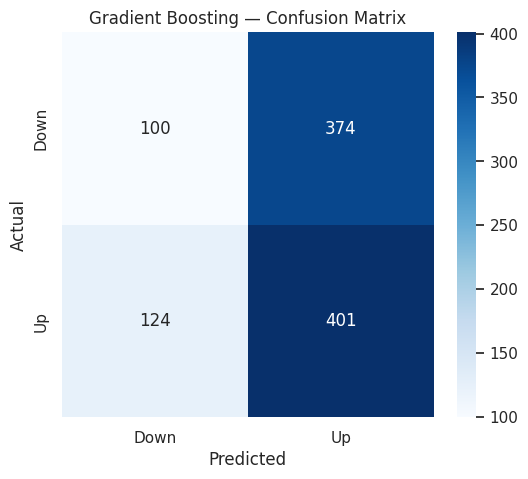

In [20]:
cm = confusion_matrix(y_test, gb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Gradient Boosting — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 21. Walk-Forward Validation — The Real Rigor Test

A single train/test split could get lucky. Walk-forward validation retrains across 5 sequential time windows and checks whether the model beats the naive baseline *consistently*, not just once.

In [21]:
tscv = TimeSeriesSplit(n_splits=5)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(model_data)):
    fold_train = model_data.iloc[train_idx]
    fold_test = model_data.iloc[test_idx]

    Xf_train, yf_train = fold_train[feature_cols], fold_train['target']
    Xf_test, yf_test = fold_test[feature_cols], fold_test['target']

    fold_model = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=42)
    fold_model.fit(Xf_train, yf_train)
    fold_preds = fold_model.predict(Xf_test)

    fold_acc = accuracy_score(yf_test, fold_preds)
    fold_naive = max(yf_test.mean(), 1 - yf_test.mean())  # naive baseline for this fold's class balance

    fold_results.append({'fold': fold + 1, 'model_accuracy': fold_acc, 'naive_baseline': fold_naive})
    print(f'Fold {fold+1}: model={fold_acc:.4f}, naive baseline={fold_naive:.4f}, beat baseline={fold_acc > fold_naive}')

fold_df = pd.DataFrame(fold_results)

Fold 1: model=0.5132, naive baseline=0.5385, beat baseline=False


Fold 2: model=0.5180, naive baseline=0.5168, beat baseline=True


Fold 3: model=0.5421, naive baseline=0.5156, beat baseline=True


Fold 4: model=0.5144, naive baseline=0.5457, beat baseline=False


Fold 5: model=0.5144, naive baseline=0.5300, beat baseline=False


## 22. Walk-Forward Results — Visualized

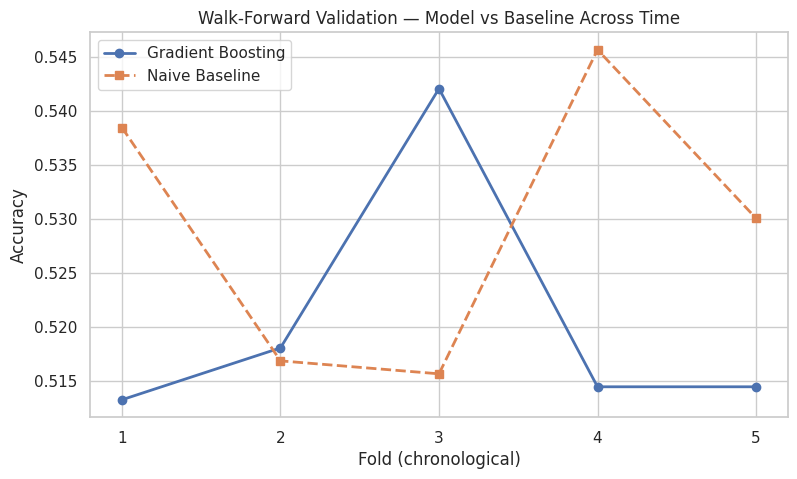


Model beat the naive baseline in 2 out of 5 folds.


In [22]:
plt.figure(figsize=(9, 5))
plt.plot(fold_df['fold'], fold_df['model_accuracy'], marker='o', label='Gradient Boosting', linewidth=2)
plt.plot(fold_df['fold'], fold_df['naive_baseline'], marker='s', label='Naive Baseline', linewidth=2, linestyle='--')
plt.xlabel('Fold (chronological)')
plt.ylabel('Accuracy')
plt.title('Walk-Forward Validation — Model vs Baseline Across Time')
plt.legend()
plt.xticks(fold_df['fold'])
plt.show()

folds_beaten = (fold_df['model_accuracy'] > fold_df['naive_baseline']).sum()
print(f'\nModel beat the naive baseline in {folds_beaten} out of {len(fold_df)} folds.')

## 23. Feature Importance

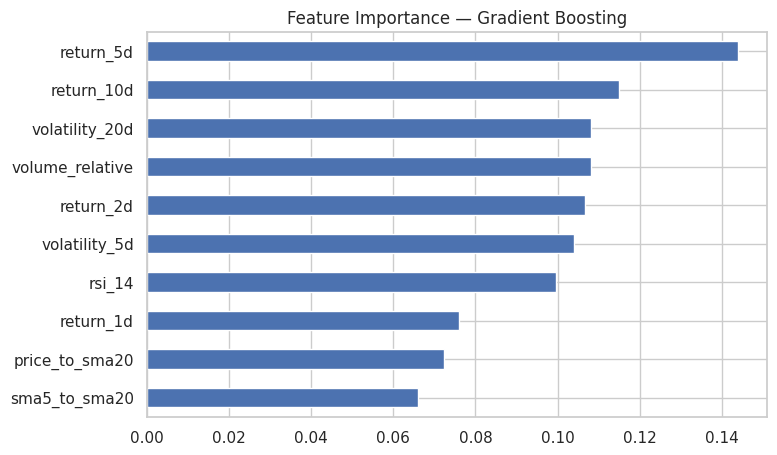

return_5d          0.143908
return_10d         0.114997
volatility_20d     0.108226
volume_relative    0.108192
return_2d          0.106656
volatility_5d      0.104109
rsi_14             0.099698
return_1d          0.075967
price_to_sma20     0.072341
sma5_to_sma20      0.065905
dtype: float64


In [23]:
importance = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importance.plot(kind='barh')
plt.title('Feature Importance — Gradient Boosting')
plt.gca().invert_yaxis()
plt.show()
print(importance)

## 24. Honest Discussion — What This Result Actually Means

**Read this section before drawing conclusions from the accuracy numbers above.**

- If the Gradient Boosting model's accuracy is only marginally above the naive/persistence baselines (which is the expected, normal outcome here), that is **not a failure of the code** — it's a correct, honest reflection of how efficient the market actually is at this level of feature complexity.
- The walk-forward results matter more than the single train/test split — a model that beats baseline in 3-4 out of 5 folds is doing something real; one that only wins in 1 fold got lucky once.
- **What's missing that real quant trading systems use:** order book microstructure, news/sentiment data, sector and macro signals, and (critically) transaction cost modeling — a strategy with 53% accuracy can still lose money after trading fees and slippage.
- **This is intentionally NOT a trading strategy.** It's a demonstration of doing stock direction prediction *correctly*: proper time-based splits, real baselines, walk-forward validation, and honest reporting — exactly what separates a credible project from an overclaimed one.

## 25. Summary

- Built real technical features (returns, moving averages, volatility, RSI, volume) from 20 years of real AAPL daily data.
- Established two real baselines (naive-always-up, persistence) that any credible model must beat.
- Trained 3 classifiers with a strict chronological train/test split — no shuffling, no lookahead leakage.
- Validated with walk-forward testing across 5 time windows, not just a single lucky split.
- Reported results honestly, including the expected limitation that stock direction prediction rarely beats ~55% accuracy — and explained why that's the correct, expected outcome rather than a bug.